Index(['student_id', 'gender', 'department', 'semester', 'internal_marks',
       'external_marks', ' total_marks', ' percentage', 'cgpa', 'grade',
       'result'],
      dtype='object')


/tmp/ipykernel_1826/199134483.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'feat',y='coef',data = imp,palette= 'coolwarm')


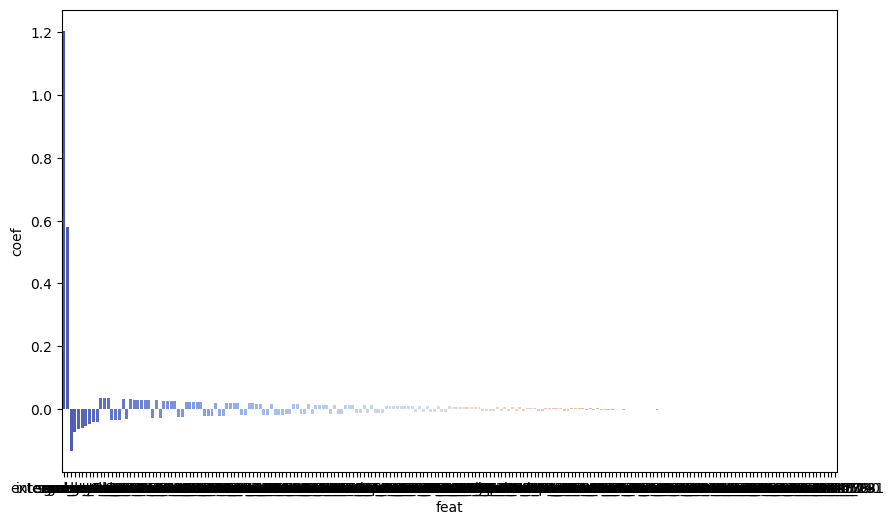

0.9998265823346666
0.0004906809486192414
0.022151319342631523


In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/student_academic_performance.csv')
print(df.columns)
df = df.drop('student_id',axis = 1)
df['gender'] = df['gender'].map({
    'Female':0,
    'Male':1
})
df['result'] = df['result'].map({
    'Pass':1,
    'Fail':0
})
df = pd.get_dummies(df,columns=['department','semester','grade'],drop_first=True)
df.head()

X = df.drop(columns=['result','cgpa',' total_marks',' percentage'],axis = 1)
y = df['cgpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x = StandardScaler()
scale_cols = ['internal_marks','external_marks']
X_train[scale_cols] = x.fit_transform(X_train[scale_cols])
X_test[scale_cols] = x.transform(X_test[scale_cols])

model =LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

imp = pd.DataFrame({
    'feat':X_train.columns,
    'coef':model.coef_})
imp['abs'] = imp['coef'].abs()
imp= imp.sort_values(by= 'abs',ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x= 'feat',y='coef',data = imp,palette= 'coolwarm')
plt.show()
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))